## Imports + Setup

In [1]:
import os
os.chdir("..")  # should be run from repo root
import torch as th
from torch.utils.data import DataLoader, TensorDataset
from diffusers.utils import logging as df_logging
from t2i_interp.utils.T2I.collect_latents import collect_latents
from t2i_interp.mapper import MLPMapper
from t2i_interp.stitch import Stitcher
from t2i_interp.utils.training import TrainingSpec, Training
from t2i_interp.t2i import T2IModel
from diffusers import AutoPipelineForText2Image
from datasets import load_dataset
from t2i_interp.utils.T2I.buffer import ActivationsDataloader, PairedLoader


/home/nirmal/miniconda3/envs/SoftREPA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nirmal/miniconda3/envs/SoftREPA/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `PYTORCH_TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Load Model

In [2]:
device = "cuda" if th.cuda.is_available() else "cpu"
model_key = "runwayml/stable-diffusion-v1-5"
init_seed = 42
save_dir = "./latents_cache/mapper"
# Initialize model once
df_logging.set_verbosity_error()

model = T2IModel(model_key, automodal=AutoPipelineForText2Image, device=device, dtype="float16")
model.pipeline.set_progress_bar_config(disable=True)

2026-02-26 02:07:07.459 | INFO     | t2i_interp.t2i:__init__:117 - Loading model runwayml/stable-diffusion-v1-5...
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 13.00it/s]


In [3]:
# ── 1. Collect activations ───────────────────────────────────────────
print("Loading dataset...")
dataset_name = "nirmalendu01/spectacles-bias-prompts"
ds_full = load_dataset(dataset_name)
ds_train = ds_full["train"]
ds_val = ds_full["validation"] if "validation" in ds_full else ds_full["test"] if "test" in ds_full else None

# If no val split, create one from train (80/20)
if ds_val is None:
    split = ds_train.train_test_split(test_size=0.2, seed=42)
    ds_train = split["train"]
    ds_val = split["test"]

layer_a = "text_encoder.text_model.final_layer_norm"
layer_b = "unet.conv_out"

Loading dataset...


Repo card metadata block was not found. Setting CardData to empty.


In [4]:

print("Collecting train latents...")
train_acta_path = collect_latents(
    accessors=[layer_a],
    dataset=ds_train,
    model=model,
    save_path=os.path.join(save_dir, "train"),
    columns=["base_prompt"],
    batch_size=4,
    guidance_scale=7.5,
    conditional_only=True,
)

train_actb_path = collect_latents(
    accessors=[layer_b],
    dataset=ds_train,
    model=model,
    save_path=os.path.join(save_dir, "train"),
    columns=["with_spectacles_prompt"],
    batch_size=4,
    guidance_scale=7.5,
    conditional_only=True,
)


# Collect Latents - Val
print("Collecting val latents...")
val_acta_path = collect_latents(
    accessors=[layer_a],
    dataset=ds_val,
    model=model,
    save_path=os.path.join(save_dir, "val"),
    columns=["base_prompt"],
    batch_size=4,
    guidance_scale=7.5,
    conditional_only=True,
)

train_actb_path = collect_latents(
    accessors=[layer_b],
    dataset=ds_val,
    model=model,
    save_path=os.path.join(save_dir, "val"),
    columns=["with_spectacles_prompt"],
    batch_size=4,
    guidance_scale=7.5,
    conditional_only=True,
)

[collect_latents] Writing tars under: ./latents_cache/mapper/train (Format: {accessor}_{column}.tar)
Using provided dataset object.


200it [00:45,  4.39it/s]


[collect_latents] Writing tars under: ./latents_cache/mapper/train (Format: {accessor}_{column}.tar)
Using provided dataset object.


200it [00:44,  4.45it/s]


[collect_latents] Writing tars under: ./latents_cache/mapper/val (Format: {accessor}_{column}.tar)
Using provided dataset object.


50it [00:11,  4.38it/s]


[collect_latents] Writing tars under: ./latents_cache/mapper/val (Format: {accessor}_{column}.tar)
Using provided dataset object.


50it [00:11,  4.44it/s]


## Create Loaders

In [5]:
# Create Loaders
print("Creating loaders...")
train_a_tar_path = os.path.join(f"{save_dir}/train", f"{layer_a}_base_prompt.tar")
train_b_tar_path = os.path.join(f"{save_dir}/train", f"{layer_b}_with_spectacles_prompt.tar")

val_a_tar_path = os.path.join(f"{save_dir}/val", f"{layer_a}_base_prompt.tar")
val_b_tar_path = os.path.join(f"{save_dir}/val", f"{layer_b}_with_spectacles_prompt.tar")

train_a_loader = ActivationsDataloader(
    paths_to_datasets=[train_a_tar_path],
    block_name=layer_a,
    batch_size=16,
    flatten=False,
    shuffle=False,
    device=device
)
train_b_loader = ActivationsDataloader(
    paths_to_datasets=[train_b_tar_path],
    block_name=layer_b,
    batch_size=16,
    flatten=False,
    shuffle=False,
    device=device
)
train_loader = PairedLoader([train_a_loader, train_b_loader])

val_a_loader = ActivationsDataloader(
    paths_to_datasets=[val_a_tar_path],
    block_name=layer_a,
    batch_size=16,
    flatten=False,
    shuffle=False,
    device=device
)
val_b_loader = ActivationsDataloader(
    paths_to_datasets=[val_b_tar_path],
    block_name=layer_b,
    batch_size=16,
    flatten=False,
    shuffle=False,
    device=device
)
val_loader = PairedLoader([val_a_loader, val_b_loader])

Creating loaders...


/home/nirmal/miniconda3/envs/SoftREPA/lib/python3.11/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


In [6]:
stitcher = Stitcher()
input_dim=77 * 768
hidden_dim=11 * 768
output_dim=4 * 64 * 64
# ── 3. Build mapper and train ────────────────────────────────────────
mapper = MLPMapper(input_dim=input_dim, output_dim=output_dim, hidden_dim=hidden_dim)

spec = TrainingSpec(
    training_function=stitcher.train_mapper,
    kwargs={
        "train_loader"    : train_loader,
        "val_loader"      : val_loader,
        "mapper"          : mapper,
        "optimizers"      : [th.optim.Adam(mapper.parameters(), lr=1e-4)],
        "num_steps"       : 1_000,
        "loss_fn"         : th.nn.MSELoss(),
        "training_device" : "cuda:0",
        "autocast_dtype"  : th.bfloat16,
        "log_steps"       : 100,
    }
)

output = Training(spec).run_trainer()
# output.preds holds the trained mapper after run_trainer() completes
trained_mapper = output.preds
print("Training complete. Mapper:", trained_mapper)


2026-02-26 02:09:09.238 | INFO     | t2i_interp.utils.runningstats:start:152 - 🔧 SimpleFileLogger started → logs/run.log
2026-02-26 02:09:09.240 | INFO     | t2i_interp.utils.runningstats:start:159 - Run config:
2026-02-26 02:09:09.241 | INFO     | t2i_interp.utils.runningstats:start:161 -   train_loader = <t2i_interp.utils.T2I.buffer.PairedLoader object at 0x7f14aaf48a90>
2026-02-26 02:09:09.242 | INFO     | t2i_interp.utils.runningstats:start:161 -   val_loader = <t2i_interp.utils.T2I.buffer.PairedLoader object at 0x7f14aa60fb90>
2026-02-26 02:09:09.243 | INFO     | t2i_interp.utils.runningstats:start:161 -   mapper = MLPMapper(
  (network): Sequential(
    (0): Linear(in_features=59136, out_features=8448, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8448, out_features=16384, bias=True)
  )
)
2026-02-26 02:09:09.244 | INFO     | t2i_interp.utils.runningstats:start:161 -   optimizers = ['Adam (\nParameter Group 0\n    amsgrad: False\n    betas: (0.9, 0.999)\n    capturable: 

Training complete. Mapper: MLPMapper(
  (network): Sequential(
    (0): Linear(in_features=59136, out_features=8448, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8448, out_features=16384, bias=True)
  )
)


## Map sample prompts

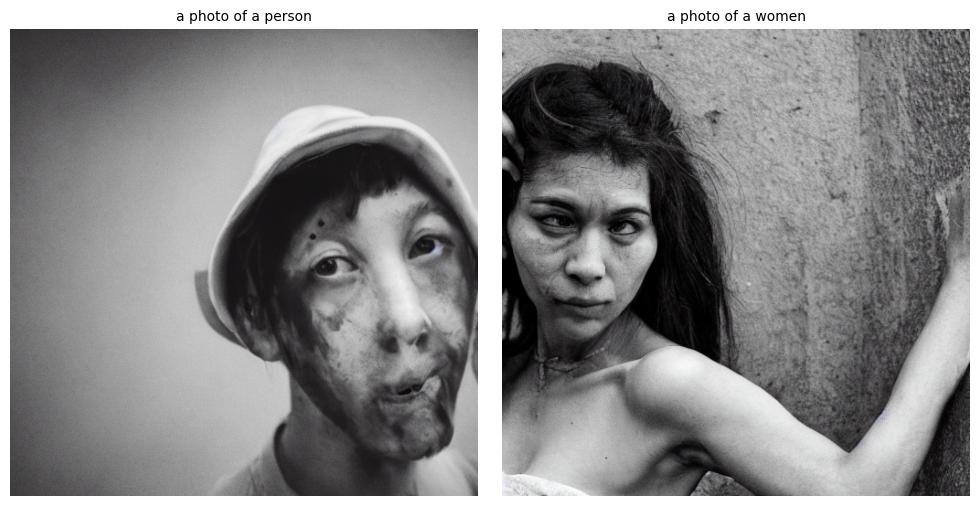

In [20]:
from t2i_interp.utils.inference import InferenceSpec, Inference
from t2i_interp.utils.plot import show_grid

prompts = ["a photo of a person", "a photo of a women"]

spec = InferenceSpec(
    name="mapper_stitch",
    inference_fn=stitcher.map,
    kwargs={
        "model"                : model, 
        "module_a"             : layer_a,   # "text_encoder.text_model.final_layer_norm"
        "module_b"             : layer_b,   # "unet.conv_out"
        "mapper"               : trained_mapper.to(device="cuda:0", dtype=th.float16),
        "prompts"              : prompts,
        "device"               : "cuda:0",
        "num_inference_steps"  : 50,
        "guidance_scale"       : 7.5,
        "inject_steps"         : [0],
    }
)

out = Inference(spec).run_inference()

# out.preds = (imgs, ...)  — map() returns a list of PIL images directly
show_grid(out.preds, prompts, cols=len(prompts))

## Diffusion Lens